In [21]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2


In [22]:

dataset = tf.keras.utils.image_dataset_from_directory(
    "data/Jewellery_Data",
    image_size=(224, 224),
    batch_size=32,
    shuffle=False
)


dataset.class_names


Found 490 files belonging to 2 classes.


['necklace', 'ring']

In [23]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.models import Model

base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

embedding_model = Model(
    inputs=base_model.input,
    outputs=GlobalAveragePooling2D()(base_model.output)
)

embedding_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,257,984 (8.61 MB)

 Trainable params: 2,223,872 (8.48 MB)

 Non-trainable params: 34,112 (133.25 KB)

In [24]:
for i, y in dataset:
    print(y)

tf.Tensor([0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0], shape=(32,), dtype=int32)
tf.Tensor([0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0], shape=(32,), dtype=int32)
tf.Tensor([0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0], shape=(32,), dtype=int32)
tf.Tensor([0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0], shape=(32,), dtype=int32)
tf.Tensor([0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0], shape=(32,), dtype=int32)
tf.Tensor([0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0], shape=(32,), dtype=int32)
tf.Tensor([0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0], shape=(32,), dtype=int32)
tf.Tensor([0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0], shape=(32,), dtype=int32)
tf.Tensor([0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0], shape=(32,), dtype=int32)
tf.Tensor([0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 

In [25]:
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

embeddings = []
labels = []

for images, y in dataset:
    images = preprocess_input(images)

    emb = embedding_model.predict(images, verbose=0)

    embeddings.append(emb)
    labels.append(y)


display(embeddings[:5])
display(labels[:5])

[array([[0.        , 0.13137089, 0.        , ..., 0.        , 1.6998881 ,
         0.4056588 ],
        [0.        , 1.952922  , 0.        , ..., 0.        , 0.        ,
         1.5070757 ],
        [0.04013858, 0.        , 0.        , ..., 0.        , 1.6376928 ,
         2.1406167 ],
        ...,
        [0.20132591, 0.        , 0.        , ..., 0.        , 1.9722371 ,
         1.5919056 ],
        [0.        , 0.5750304 , 0.038164  , ..., 0.        , 0.7689361 ,
         2.5141277 ],
        [0.        , 0.02263332, 0.        , ..., 0.        , 0.3553981 ,
         2.6110547 ]], shape=(32, 1280), dtype=float32),
 array([[0.0000000e+00, 2.3162296e-01, 0.0000000e+00, ..., 0.0000000e+00,
         2.0332146e-01, 6.2055248e-01],
        [5.5598248e-02, 0.0000000e+00, 0.0000000e+00, ..., 0.0000000e+00,
         1.6162008e+00, 1.9845631e+00],
        [0.0000000e+00, 0.0000000e+00, 0.0000000e+00, ..., 0.0000000e+00,
         1.3105195e+00, 1.0922878e+00],
        ...,
        [8.8882089e-0

[<tf.Tensor: shape=(32,), dtype=int32, numpy=
 array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0], dtype=int32)>,
 <tf.Tensor: shape=(32,), dtype=int32, numpy=
 array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0], dtype=int32)>,
 <tf.Tensor: shape=(32,), dtype=int32, numpy=
 array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0], dtype=int32)>,
 <tf.Tensor: shape=(32,), dtype=int32, numpy=
 array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0], dtype=int32)>,
 <tf.Tensor: shape=(32,), dtype=int32, numpy=
 array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0], dtype=int32)>]

In [26]:
import numpy as np

embeddings = np.concatenate(embeddings)
labels = np.concatenate(labels)

print(embeddings.shape)
print(labels.shape)

(490, 1280)
(490,)


In [27]:
from pathlib import Path

folders = [str(p) for p in Path("data/Jewellery_Data/necklace").iterdir() if p.is_file()]

print(folders[:5])

['data/Jewellery_Data/necklace/necklace_86.jpg', 'data/Jewellery_Data/necklace/necklace_128.jpg', 'data/Jewellery_Data/necklace/necklace_116.jpg', 'data/Jewellery_Data/necklace/necklace_39.jpg', 'data/Jewellery_Data/necklace/necklace_77.jpg']


In [28]:
pip install pillow

Note: you may need to restart the kernel to use updated packages.


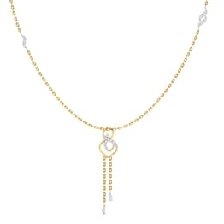

In [29]:
from tensorflow.keras.utils import load_img, img_to_array
test_image_path = folders[4]
image = load_img(
    test_image_path,
    target_size=(224, 224)
)

image

In [30]:
image = img_to_array(image)

print(image.shape)

(224, 224, 3)


In [31]:
import numpy as np
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

image = np.expand_dims(image, axis=0)
image = preprocess_input(image)

embedding = embedding_model.predict(image)

print(embedding.shape)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
(1, 1280)


In [32]:
pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


In [33]:
def get_embedding(image_path):
    image = load_img(
        image_path,
        target_size=(224, 224)
    )

    image = img_to_array(image)
    image = np.expand_dims(image, axis=0)
    image = preprocess_input(image)

    return embedding_model.predict(image, verbose=0)

In [34]:
!pip install scikit-learn

In [35]:
from sklearn.metrics.pairwise import cosine_similarity


test_embedding = get_embedding(test_image_path)

similarities = cosine_similarity(
    test_embedding,
    embeddings
)[0]

top5 = np.argsort(similarities)[-5:][::-1]

for rank, index in enumerate(top5, start=1):
    print(
        f"{rank}. "
        f"Similarity: {similarities[index]:.4f}, "
        f"Label: {labels[index]}"
    )

1. Similarity: 0.9685, Label: 0
2. Similarity: 0.9183, Label: 0
3. Similarity: 0.9104, Label: 0
4. Similarity: 0.8936, Label: 0
5. Similarity: 0.8551, Label: 0


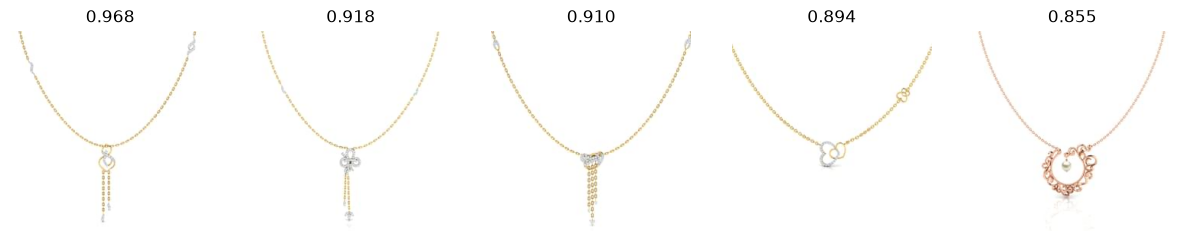

In [36]:
import matplotlib.pyplot as plt
from tensorflow.keras.utils import load_img

plt.figure(figsize=(15, 3))

for i, index in enumerate(top5):
    plt.subplot(1, 5, i + 1)
    plt.imshow(load_img(dataset.file_paths[index]))
    plt.title(f"{similarities[index]:.3f}")
    plt.axis("off")

plt.show()